# Análisis de Datasets de Clima y Paneles Solares

Este notebook analiza todos los archivos CSV en la carpeta `datasets/clima paneles/` para entender su estructura y contenido.

## Archivos a analizar:
1. Dataset-SolarTechLab.csv (26M)
2. Solar Power Plant Data.csv (398K)
3. dataset.csv (4.0M)
4. solar_data.csv (135K)
5. weather_data.csv (99M)

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [2]:
# Definir ruta base
BASE_PATH = Path('datasets/clima paneles')

# Lista de archivos CSV
csv_files = [
    'Dataset-SolarTechLab.csv',
    'Solar Power Plant Data.csv',
    'dataset.csv',
    'solar_data.csv',
    'weather_data.csv'
]

print(f"Ruta base: {BASE_PATH}")
print(f"Archivos a analizar: {len(csv_files)}")

Ruta base: datasets/clima paneles
Archivos a analizar: 5


## Función auxiliar para análisis exploratorio

In [3]:
def analizar_csv(filepath, nombre_archivo, sample_rows=5):
    """
    Analiza un archivo CSV y muestra información detallada.
    
    Args:
        filepath: Ruta completa al archivo CSV
        nombre_archivo: Nombre del archivo para el título
        sample_rows: Número de filas de muestra a mostrar
    """
    print("="*100)
    print(f"📊 ANÁLISIS: {nombre_archivo}")
    print("="*100)
    
    try:
        # Leer CSV
        df = pd.read_csv(filepath)
        
        # 1. Información básica
        print(f"\n📏 DIMENSIONES:")
        print(f"   Filas: {df.shape[0]:,}")
        print(f"   Columnas: {df.shape[1]}")
        print(f"   Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        # 2. Columnas y tipos de datos
        print(f"\n📋 COLUMNAS Y TIPOS DE DATOS:")
        info_df = pd.DataFrame({
            'Columna': df.columns,
            'Tipo': df.dtypes.values,
            'No Nulos': df.count().values,
            '% Nulos': ((df.isnull().sum() / len(df)) * 100).values.round(2)
        })
        print(info_df.to_string(index=False))
        
        # 3. Primeras filas
        print(f"\n👀 PRIMERAS {sample_rows} FILAS:")
        display(df.head(sample_rows))
        
        # 4. Últimas filas
        print(f"\n👀 ÚLTIMAS {sample_rows} FILAS:")
        display(df.tail(sample_rows))
        
        # 5. Estadísticas descriptivas para columnas numéricas
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            print(f"\n📈 ESTADÍSTICAS DESCRIPTIVAS (Columnas numéricas):")
            display(df[numeric_cols].describe().round(2))
        
        # 6. Valores únicos para columnas categóricas (si hay pocas)
        categorical_cols = df.select_dtypes(include=['object']).columns
        if len(categorical_cols) > 0:
            print(f"\n🏷️  COLUMNAS CATEGÓRICAS:")
            for col in categorical_cols:
                n_unique = df[col].nunique()
                if n_unique <= 20:  # Solo mostrar si hay pocas categorías
                    print(f"   {col}: {n_unique} valores únicos")
                    print(f"      {df[col].value_counts().head(10).to_dict()}")
                else:
                    print(f"   {col}: {n_unique} valores únicos (demasiados para listar)")
        
        # 7. Detectar posibles columnas de fecha
        print(f"\n📅 DETECCIÓN DE COLUMNAS DE FECHA:")
        date_candidates = [col for col in df.columns if any(word in col.lower() 
                          for word in ['date', 'time', 'timestamp', 'fecha', 'hora'])]
        if date_candidates:
            print(f"   Posibles columnas de fecha: {date_candidates}")
            for col in date_candidates:
                print(f"   {col}: Ejemplos -> {df[col].head(3).tolist()}")
        else:
            print("   No se detectaron columnas de fecha obvias")
        
        # 8. Resumen de valores nulos
        null_counts = df.isnull().sum()
        if null_counts.sum() > 0:
            print(f"\n⚠️  VALORES NULOS:")
            print(f"   Total de valores nulos: {null_counts.sum():,}")
            print(f"   Columnas con nulos:")
            for col in null_counts[null_counts > 0].index:
                pct = (null_counts[col] / len(df)) * 100
                print(f"      {col}: {null_counts[col]:,} ({pct:.2f}%)")
        else:
            print(f"\n✅ No hay valores nulos en este dataset")
        
        # 9. Duplicados
        duplicates = df.duplicated().sum()
        if duplicates > 0:
            print(f"\n⚠️  FILAS DUPLICADAS: {duplicates:,} ({(duplicates/len(df)*100):.2f}%)")
        else:
            print(f"\n✅ No hay filas duplicadas")
        
        print("\n" + "="*100 + "\n")
        
        return df
        
    except Exception as e:
        print(f"❌ Error al procesar {nombre_archivo}: {str(e)}")
        print("\n" + "="*100 + "\n")
        return None

## 1. Dataset-SolarTechLab.csv

In [4]:
df1 = analizar_csv(BASE_PATH / 'Dataset-SolarTechLab.csv', 'Dataset-SolarTechLab.csv')

📊 ANÁLISIS: Dataset-SolarTechLab.csv

📏 DIMENSIONES:
   Filas: 525,601
   Columnas: 1
   Tamaño en memoria: 49.65 MB

📋 COLUMNAS Y TIPOS DE DATOS:
                               Columna   Tipo  No Nulos  % Nulos
Time;PV_Power;T_air;G_h;G_tilt;W_s;W_d object    525601      0.0

👀 PRIMERAS 5 FILAS:


,Time;PV_Power;T_air;G_h;G_tilt;W_s;W_d
0,01-Jan-2017 00:00:00;NaN;0.74;0;0;0.3;296.4
1,01-Jan-2017 00:01:00;NaN;0.67;0;0;0.47;269.2
2,01-Jan-2017 00:02:00;NaN;0.57;0;0;0.84;265.3
3,01-Jan-2017 00:03:00;NaN;0.53;0;0;0.63;275.4
4,01-Jan-2017 00:04:00;NaN;0.53;0;0;0.58;265.3



👀 ÚLTIMAS 5 FILAS:


,Time;PV_Power;T_air;G_h;G_tilt;W_s;W_d
525596,31-Dec-2017 23:56:00;NaN;2.91;0;0;0.41;68.2
525597,31-Dec-2017 23:57:00;NaN;2.85;0;0;1.01;42.8
525598,31-Dec-2017 23:58:00;NaN;2.83;0;0;1.22;46.6
525599,31-Dec-2017 23:59:00;NaN;2.84;0;0;0.95;63.8
525600,01-Jan-2018 00:00:00;NaN;NaN;NaN;NaN;NaN;NaN



🏷️  COLUMNAS CATEGÓRICAS:
   Time;PV_Power;T_air;G_h;G_tilt;W_s;W_d: 525601 valores únicos (demasiados para listar)

📅 DETECCIÓN DE COLUMNAS DE FECHA:
   Posibles columnas de fecha: ['Time;PV_Power;T_air;G_h;G_tilt;W_s;W_d']
   Time;PV_Power;T_air;G_h;G_tilt;W_s;W_d: Ejemplos -> ['01-Jan-2017 00:00:00;NaN;0.74;0;0;0.3;296.4', '01-Jan-2017 00:01:00;NaN;0.67;0;0;0.47;269.2', '01-Jan-2017 00:02:00;NaN;0.57;0;0;0.84;265.3']

✅ No hay valores nulos en este dataset

✅ No hay filas duplicadas




## 2. Solar Power Plant Data.csv

In [5]:
df2 = analizar_csv(BASE_PATH / 'Solar Power Plant Data.csv', 'Solar Power Plant Data.csv')

📊 ANÁLISIS: Solar Power Plant Data.csv

📏 DIMENSIONES:
   Filas: 8,760
   Columnas: 8
   Tamaño en memoria: 1.01 MB

📋 COLUMNAS Y TIPOS DE DATOS:
            Columna    Tipo  No Nulos  % Nulos
     Date-Hour(NMT)  object      8760      0.0
          WindSpeed float64      8760      0.0
           Sunshine   int64      8760      0.0
        AirPressure float64      8760      0.0
          Radiation float64      8760      0.0
     AirTemperature float64      8760      0.0
RelativeAirHumidity   int64      8760      0.0
   SystemProduction float64      8760      0.0

👀 PRIMERAS 5 FILAS:


,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0



👀 ÚLTIMAS 5 FILAS:


,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
8755,31.12.2017-19:00,4.1,0,988.2,-4.8,-0.7,94,0.0
8756,31.12.2017-20:00,2.1,0,987.3,-5.0,-0.3,95,0.0
8757,31.12.2017-21:00,1.8,0,986.7,-5.3,0.2,93,0.0
8758,31.12.2017-22:00,2.2,0,986.0,-5.4,0.3,92,0.0
8759,31.12.2017-23:00,2.4,0,985.6,-5.9,0.4,96,0.0



📈 ESTADÍSTICAS DESCRIPTIVAS (Columnas numéricas):


,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,2.64,11.18,1010.36,97.54,6.98,76.72,684.75
std,1.63,21.17,12.79,182.34,7.60,19.28,1487.45
min,0.00,0.00,965.90,-9.30,-12.40,13.00,0.00
25%,1.40,0.00,1002.80,-6.20,0.50,64.00,0.00
50%,2.30,0.00,1011.00,-1.40,6.40,82.00,0.00
75%,3.60,7.00,1018.20,115.60,13.40,93.00,464.25
max,10.90,60.00,1047.30,899.70,27.10,100.00,7701.00



🏷️  COLUMNAS CATEGÓRICAS:
   Date-Hour(NMT): 8760 valores únicos (demasiados para listar)

📅 DETECCIÓN DE COLUMNAS DE FECHA:
   Posibles columnas de fecha: ['Date-Hour(NMT)']
   Date-Hour(NMT): Ejemplos -> ['01.01.2017-00:00', '01.01.2017-01:00', '01.01.2017-02:00']

✅ No hay valores nulos en este dataset

✅ No hay filas duplicadas




## 3. dataset.csv

In [7]:
df3 = analizar_csv(BASE_PATH / 'dataset.csv', 'dataset.csv')

📊 ANÁLISIS: dataset.csv

📏 DIMENSIONES:
   Filas: 184,052
   Columnas: 3
   Tamaño en memoria: 4.21 MB

📋 COLUMNAS Y TIPOS DE DATOS:
     Columna    Tipo  No Nulos  % Nulos
   Timestamp float64    184052      0.0
  Production float64    184052      0.0
HumanWeather float64    184052      0.0

👀 PRIMERAS 5 FILAS:


,Timestamp,Production,HumanWeather
0,1.656536e+09,0.0,0.0
1,1.656537e+09,0.0,0.0
2,1.656537e+09,0.0,0.0
3,1.656537e+09,0.0,0.0
4,1.656538e+09,0.0,0.0



👀 ÚLTIMAS 5 FILAS:


,Timestamp,Production,HumanWeather
184047,1.711751e+09,0.0,0.0
184048,1.711751e+09,0.0,0.0
184049,1.711751e+09,0.0,0.0
184050,1.711752e+09,0.0,0.0
184051,1.711752e+09,0.0,0.0



📈 ESTADÍSTICAS DESCRIPTIVAS (Columnas numéricas):


,Timestamp,Production,HumanWeather
count,1.840520e+05,184052.00,184052.00
mean,1.684144e+09,0.68,1.52
std,1.593950e+07,1.32,2.20
min,1.656536e+09,0.00,0.00
25%,1.670340e+09,0.00,0.00
50%,1.684144e+09,0.00,0.00
75%,1.697948e+09,0.63,3.00
max,1.711752e+09,6.50,9.00



📅 DETECCIÓN DE COLUMNAS DE FECHA:
   Posibles columnas de fecha: ['Timestamp']
   Timestamp: Ejemplos -> [1656536400.0, 1656536700.002, 1656537000.003]

✅ No hay valores nulos en este dataset

✅ No hay filas duplicadas




## 4. solar_data.csv

In [8]:
df4 = analizar_csv(BASE_PATH / 'solar_data.csv', 'solar_data.csv')

📊 ANÁLISIS: solar_data.csv

📏 DIMENSIONES:
   Filas: 1,009
   Columnas: 14
   Tamaño en memoria: 0.16 MB

📋 COLUMNAS Y TIPOS DE DATOS:
          Columna    Tipo  No Nulos  % Nulos
        Timestamp  object      1009      0.0
         Air_Temp float64      1009      0.0
Relative_Humidity float64      1009      0.0
       Wind_Speed float64      1009      0.0
   Wind_Direction float64      1009      0.0
  Solar_Radiation float64      1009      0.0
            RTD_1 float64      1009      0.0
            RTD_2 float64      1009      0.0
            RTD_3 float64      1009      0.0
            RTD_4 float64      1009      0.0
            RTD_5 float64      1009      0.0
    Array_Voltage float64      1009      0.0
    Array_Current float64      1009      0.0
  Power_Generated float64      1009      0.0

👀 PRIMERAS 5 FILAS:


,Timestamp,Air_Temp,Relative_Humidity,Wind_Speed,Wind_Direction,Solar_Radiation,RTD_1,RTD_2,RTD_3,RTD_4,RTD_5,Array_Voltage,Array_Current,Power_Generated
0,27-04-2022 15:32,43.349172,12.790256,0.533333,118.786620,707.53384,98.289640,94.283552,89.002824,93.334288,94.142984,80.178232,5.364869,430.14572
1,27-04-2022 15:34,43.433980,11.468986,1.866667,84.681408,710.46328,98.377480,94.177872,89.334664,93.633208,94.107592,80.266728,5.366041,430.71452
2,27-04-2022 15:36,43.286580,11.047298,2.866667,40.807156,695.51016,97.868064,93.703480,88.844592,92.982568,93.650656,80.187416,5.365501,430.24568
3,27-04-2022 15:38,43.523020,12.058292,0.000000,66.390848,696.24472,101.470960,97.112320,91.963472,96.146384,97.147776,80.727760,5.364512,433.06504
4,27-04-2022 15:40,43.728656,10.722330,2.266667,2.127408,674.05752,101.664240,97.253520,91.980872,96.110968,97.341296,80.500312,5.365144,431.89576



👀 ÚLTIMAS 5 FILAS:


,Timestamp,Air_Temp,Relative_Humidity,Wind_Speed,Wind_Direction,Solar_Radiation,RTD_1,RTD_2,RTD_3,RTD_4,RTD_5,Array_Voltage,Array_Current,Power_Generated
1004,29-04-2022 01:00,16.580318,43.276824,0.0,49.674388,-0.243156,23.969398,25.226270,24.800780,24.674114,24.832156,2.833721,5.398601,15.298130
1005,29-04-2022 01:02,16.336292,42.395772,0.0,348.423320,-0.344048,23.891640,25.166720,24.720160,24.610228,24.766238,2.840954,5.398601,15.337176
1006,29-04-2022 01:04,16.226494,42.390788,0.0,43.298232,-0.446709,23.834920,25.131226,24.673068,24.576700,24.728590,2.841992,5.398601,15.342778
1007,29-04-2022 01:06,16.157694,43.270232,0.0,218.255380,-0.496269,23.777128,25.095664,24.602908,24.529578,24.690848,2.839916,5.398421,15.331064
1008,29-04-2022 01:08,16.222518,44.301432,0.0,210.405520,-0.496269,23.777128,25.081022,24.579838,24.539022,24.686726,2.831677,5.398421,15.286582



📈 ESTADÍSTICAS DESCRIPTIVAS (Columnas numéricas):


,Air_Temp,Relative_Humidity,Wind_Speed,Wind_Direction,Solar_Radiation,RTD_1,RTD_2,RTD_3,RTD_4,RTD_5,Array_Voltage,Array_Current,Power_Generated
count,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00
mean,25.35,31.81,0.18,210.65,224.05,47.16,46.95,45.76,46.67,46.98,34.11,5.38,183.15
std,11.43,12.33,0.43,62.05,357.58,33.98,31.63,30.66,31.94,32.07,31.01,0.02,166.30
min,12.08,10.65,0.00,1.58,-0.84,19.74,21.19,20.74,20.62,20.74,1.57,5.35,8.49
25%,16.96,20.02,0.00,194.26,-0.13,23.85,25.24,24.74,24.58,24.77,2.66,5.36,14.35
50%,19.88,34.88,0.00,212.51,1.77,27.45,28.79,28.10,27.97,28.19,51.30,5.39,276.00
75%,32.72,42.21,0.00,231.05,285.77,66.31,64.87,65.29,66.75,66.13,63.55,5.40,341.08
max,49.63,51.49,2.93,385.63,1132.13,116.77,111.63,109.62,111.68,111.63,81.78,5.41,438.56



🏷️  COLUMNAS CATEGÓRICAS:
   Timestamp: 1009 valores únicos (demasiados para listar)

📅 DETECCIÓN DE COLUMNAS DE FECHA:
   Posibles columnas de fecha: ['Timestamp']
   Timestamp: Ejemplos -> ['27-04-2022 15:32', '27-04-2022 15:34', '27-04-2022 15:36']

✅ No hay valores nulos en este dataset

✅ No hay filas duplicadas




## 5. weather_data.csv

In [9]:
df5 = analizar_csv(BASE_PATH / 'weather_data.csv', 'weather_data.csv')

📊 ANÁLISIS: weather_data.csv

📏 DIMENSIONES:
   Filas: 1,000,000
   Columnas: 6
   Tamaño en memoria: 150.30 MB

📋 COLUMNAS Y TIPOS DE DATOS:
         Columna    Tipo  No Nulos  % Nulos
        Location  object   1000000      0.0
       Date_Time  object   1000000      0.0
   Temperature_C float64   1000000      0.0
    Humidity_pct float64   1000000      0.0
Precipitation_mm float64   1000000      0.0
  Wind_Speed_kmh float64   1000000      0.0

👀 PRIMERAS 5 FILAS:


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622



👀 ÚLTIMAS 5 FILAS:


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
999995,Dallas,2024-01-01 20:29:48,23.416877,37.705024,3.819833,16.538119
999996,San Antonio,2024-01-20 15:59:48,6.759080,40.731036,8.182785,29.005558
999997,New York,2024-04-14 08:30:09,15.664465,62.201884,3.987558,0.403909
999998,Chicago,2024-05-12 20:10:43,18.999994,63.703245,4.294325,6.326036
999999,New York,2024-04-16 16:11:52,10.725351,43.804584,1.883292,15.363828



📈 ESTADÍSTICAS DESCRIPTIVAS (Columnas numéricas):


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000.00,1000000.00,1000000.00,1000000.00
mean,14.78,60.02,5.11,15.00
std,14.48,17.32,2.95,8.66
min,-19.97,30.00,0.00,0.00
25%,2.27,45.01,2.58,7.49
50%,14.78,60.02,5.11,14.99
75%,27.27,75.04,7.61,22.51
max,40.00,90.00,14.97,30.00



🏷️  COLUMNAS CATEGÓRICAS:
   Location: 10 valores únicos
      {'Phoenix': 100209, 'Chicago': 100164, 'Philadelphia': 100122, 'Houston': 100076, 'New York': 99972, 'San Antonio': 99962, 'Dallas': 99936, 'Los Angeles': 99922, 'San Jose': 99863, 'San Diego': 99774}
   Date_Time: 959526 valores únicos (demasiados para listar)

📅 DETECCIÓN DE COLUMNAS DE FECHA:
   Posibles columnas de fecha: ['Date_Time']
   Date_Time: Ejemplos -> ['2024-01-14 21:12:46', '2024-05-17 15:22:10', '2024-05-11 09:30:59']

✅ No hay valores nulos en este dataset

✅ No hay filas duplicadas




## Resumen comparativo de todos los datasets

📊 COMPARACIÓN DE TODOS LOS DATASETS


,Dataset,Filas,Columnas,Tamaño (MB),Cols Numéricas,Cols Categóricas,Valores Nulos,% Nulos
0,Dataset-SolarTechLab,"525,601",1,49.65,0,1,0,0.00%
1,Solar Power Plant Data,"8,760",8,1.01,7,1,0,0.00%
2,dataset,"184,052",3,4.21,3,0,0,0.00%
3,solar_data,"1,009",14,0.16,13,1,0,0.00%
4,weather_data,"1,000,000",6,150.30,4,2,0,0.00%


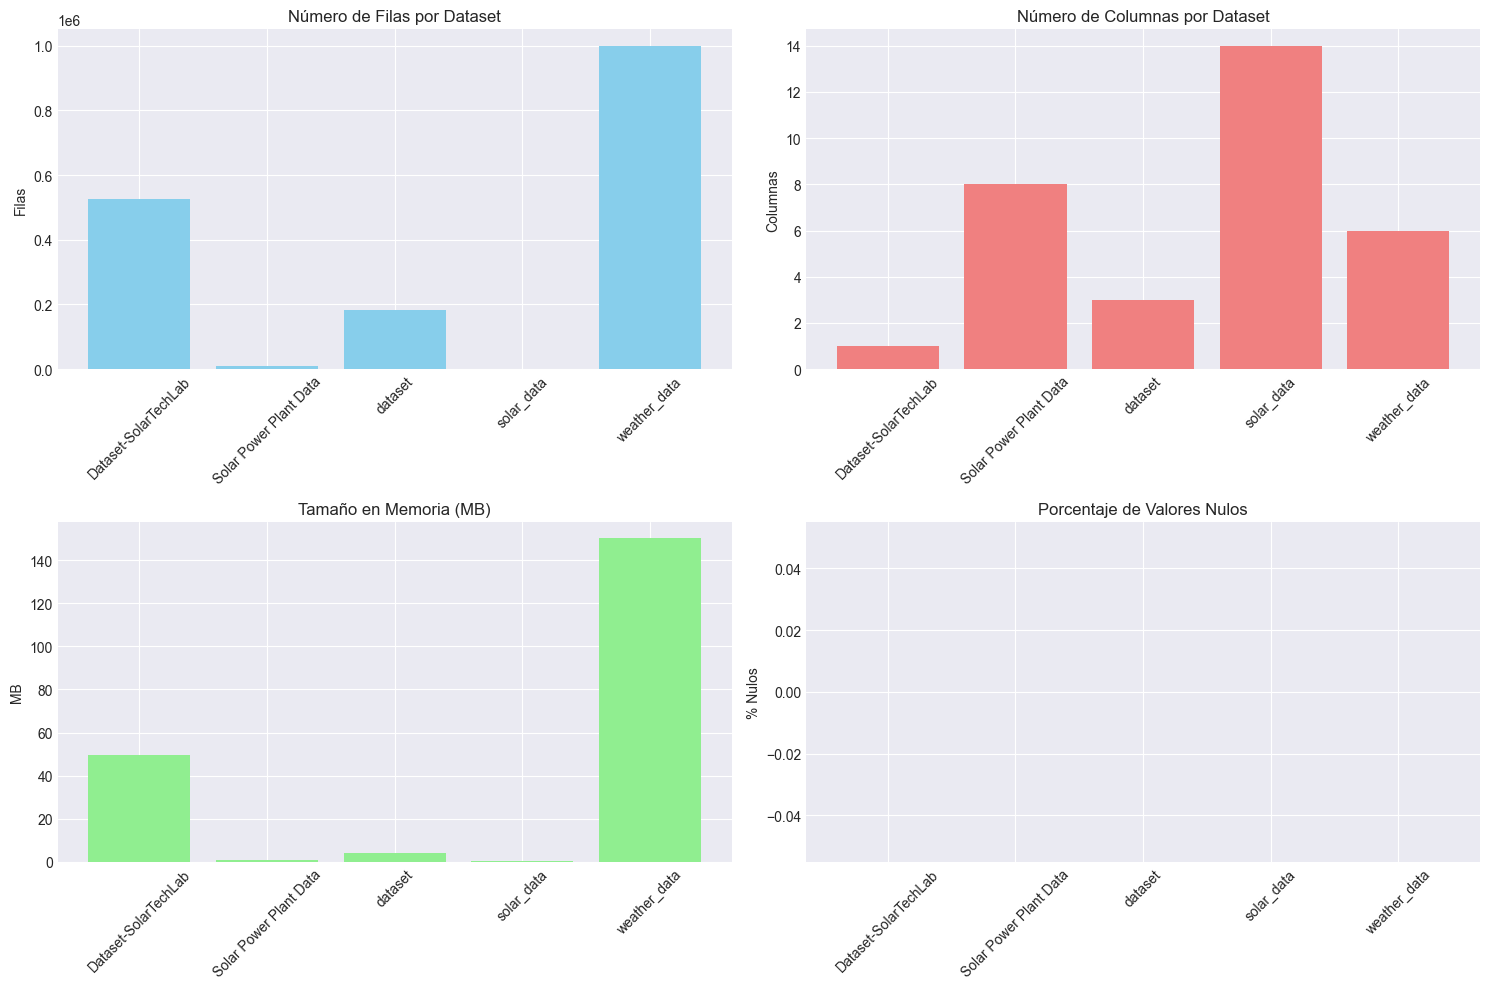


✅ Análisis completado exitosamente


In [10]:
# Crear tabla comparativa
datasets = {
    'Dataset-SolarTechLab': df1,
    'Solar Power Plant Data': df2,
    'dataset': df3,
    'solar_data': df4,
    'weather_data': df5
}

# Filtrar datasets que se cargaron exitosamente
datasets_loaded = {name: df for name, df in datasets.items() if df is not None}

if datasets_loaded:
    print("="*100)
    print("📊 COMPARACIÓN DE TODOS LOS DATASETS")
    print("="*100)
    
    comparison_data = []
    for name, df in datasets_loaded.items():
        comparison_data.append({
            'Dataset': name,
            'Filas': f"{df.shape[0]:,}",
            'Columnas': df.shape[1],
            'Tamaño (MB)': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}",
            'Cols Numéricas': len(df.select_dtypes(include=[np.number]).columns),
            'Cols Categóricas': len(df.select_dtypes(include=['object']).columns),
            'Valores Nulos': f"{df.isnull().sum().sum():,}",
            '% Nulos': f"{(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df)
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Gráfico 1: Número de filas
    rows_data = [df.shape[0] for df in datasets_loaded.values()]
    axes[0, 0].bar(datasets_loaded.keys(), rows_data, color='skyblue')
    axes[0, 0].set_title('Número de Filas por Dataset')
    axes[0, 0].set_ylabel('Filas')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Gráfico 2: Número de columnas
    cols_data = [df.shape[1] for df in datasets_loaded.values()]
    axes[0, 1].bar(datasets_loaded.keys(), cols_data, color='lightcoral')
    axes[0, 1].set_title('Número de Columnas por Dataset')
    axes[0, 1].set_ylabel('Columnas')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Gráfico 3: Tamaño en memoria
    size_data = [df.memory_usage(deep=True).sum() / 1024**2 for df in datasets_loaded.values()]
    axes[1, 0].bar(datasets_loaded.keys(), size_data, color='lightgreen')
    axes[1, 0].set_title('Tamaño en Memoria (MB)')
    axes[1, 0].set_ylabel('MB')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Gráfico 4: Porcentaje de valores nulos
    null_pct_data = [(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100) for df in datasets_loaded.values()]
    axes[1, 1].bar(datasets_loaded.keys(), null_pct_data, color='lightyellow')
    axes[1, 1].set_title('Porcentaje de Valores Nulos')
    axes[1, 1].set_ylabel('% Nulos')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Análisis completado exitosamente")
else:
    print("❌ No se pudo cargar ningún dataset")

## Conclusiones y Recomendaciones

En esta sección puedes agregar tus observaciones sobre:
- ¿Cuál dataset es más útil para tu proyecto?
- ¿Qué variables son las más relevantes?
- ¿Qué limpieza de datos es necesaria?
- ¿Cómo se relacionan entre sí los diferentes datasets?

In [ ]:
# Espacio para análisis adicional o exploración específica